# KS 1 — What kinetic segregation is, and why it needs a simulation

Estimated time: 15–20 minutes

## Prerequisites
None. This notebook runs no simulation and needs only `numpy` and `matplotlib`.
It is the conceptual entry point for the kinetic-segregation (KS) model.

## Learning aims
- **Primary scientific aim**: state the kinetic-segregation hypothesis precisely
  enough to say what would falsify it, in terms of molecular dimensions.
- **Secondary modelling aim**: explain why this hypothesis needs a *spatial,
  stochastic* model rather than a rate equation.

## Success criteria
By the end you can answer, without looking anything up:
- Why a **size** difference between two proteins can act as a **signal**.
- What physically resists the membrane deformation the hypothesis requires.
- Why "CD45 is excluded" is a statement about a *distribution*, not a yes/no fact.


## Why this matters

A T cell has to solve a discrimination problem that looks impossible. Its receptor
must ignore the overwhelming majority of peptide–MHC complexes it touches — those
displaying the body's own proteins — and respond to a handful of foreign ones, often
present at a few copies per target cell. The chemical difference between "self" and
"foreign" here can be a single amino acid, and the binding affinities involved
overlap heavily.

So the receptor cannot be doing this on binding energy alone. Something else must
amplify a small chemical difference into an all-or-nothing cellular decision.

**Kinetic segregation** (Davis & van der Merwe) proposes that part of the answer is
not chemistry at all, but *geometry*.

## The hypothesis in one paragraph

The TCR signals by having the tails of its CD3 chains phosphorylated on motifs
called ITAMs. Phosphorylation is a tug-of-war between a kinase (**Lck**, which adds
phosphates) and a phosphatase (**CD45**, which removes them). At rest the phosphatase
wins, and the receptor stays silent.

Now look at the sizes. When a TCR engages a peptide–MHC on the opposing cell, it
forms a bridge that holds the two membranes about **13 nm** apart. CD45 carries a
large, rigid extracellular domain roughly **50 nm** tall. It simply does not fit in a
13 nm gap.

So wherever a TCR is bound, the membranes are pulled close, CD45 is sterically
excluded, the phosphatase side of the tug-of-war is locally removed — and
phosphorylation runs away. **The receptor's own binding creates the zone in which its
signal can survive.**

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ks_tutorial import COLOR_CD45, COLOR_PMHC, COLOR_TCR, DEFAULTS

H_BOND = DEFAULTS["h0_tcr"]        # 13 nm — TCR-pMHC bridge
H_CD45 = DEFAULTS["cd45_height"]   # 50 nm — CD45 ectodomain
H_BULK = DEFAULTS["init_height"]   # 70 nm — resting separation
print(f"TCR-pMHC bridge {H_BOND:.0f} nm | CD45 ectodomain {H_CD45:.0f} nm "
      f"| resting gap {H_BULK:.0f} nm")

TCR-pMHC bridge 13 nm | CD45 ectodomain 50 nm | resting gap 70 nm


### A picture of the size mismatch

The figure below is drawn to scale from those three numbers — the same constants the
simulator uses (`src/simulation.h`). The left panel is a side view of the contact;
the right panel is the whole hypothesis reduced to one inequality.

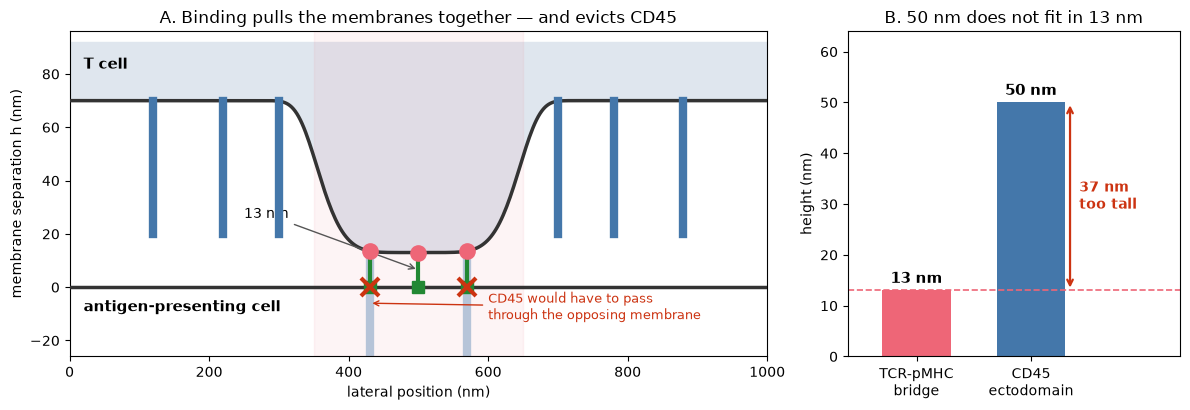

In [2]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 4.2),
                             gridspec_kw={"width_ratios": [2.1, 1]})

# ---- Panel A: side view of a contact zone -------------------------------
x = np.linspace(0, 1000, 400)
# Flat-bottomed well: bound TCRs pin the membrane at h0_tcr across the contact
# zone, so a super-Gaussian is a better cartoon than a plain Gaussian.
h = H_BULK - (H_BULK - H_BOND) * np.exp(-(((x - 500) / 150.0) ** 6))

ax.fill_between(x, h, H_BULK + 22, color="#dfe6ee", zorder=0)
ax.plot(x, h, color="#333333", lw=2.5, zorder=3)          # T-cell membrane
ax.axhline(0, color="#333333", lw=2.5, zorder=3)          # APC membrane
ax.text(20, H_BULK + 12, "T cell", fontsize=11, weight="bold")
ax.text(20, -9, "antigen-presenting cell", fontsize=11, weight="bold")

# TCR-pMHC bridges inside the contact zone.
for xb in (430, 500, 570):
    hb = np.interp(xb, x, h)
    ax.plot([xb, xb], [0, hb], color=COLOR_PMHC, lw=3, zorder=4)
    ax.plot(xb, hb, "o", color=COLOR_TCR, ms=11, zorder=5)
    ax.plot(xb, 0, "s", color=COLOR_PMHC, ms=8, zorder=5)

# CD45 hangs from the T-cell membrane toward the APC. Where the gap is wider
# than its ectodomain it sits comfortably; inside the contact zone the same
# molecule would have to pass through the opposing membrane, so it is shown
# ghosted and clipping below zero. That clash IS the mechanism.
for xc in (120, 220, 300, 700, 780, 880):
    hc = np.interp(xc, x, h)
    ax.plot([xc, xc], [hc - H_CD45, hc], color=COLOR_CD45, lw=6, zorder=4)
for xc in (430, 570):
    hc = np.interp(xc, x, h)
    ax.plot([xc, xc], [hc - H_CD45, hc], color=COLOR_CD45, lw=6, alpha=0.38, zorder=2)
    # Mark the collision at the opposing membrane, not at the (clipped) bar end.
    ax.plot(xc, 0, "x", color="#CC3311", ms=13, mew=3, zorder=6)

ax.axvspan(350, 650, color=COLOR_TCR, alpha=0.07, zorder=1)
ax.annotate("CD45 would have to pass\nthrough the opposing membrane",
            xy=(430, -6), xytext=(600, -12), fontsize=9, color="#CC3311",
            arrowprops=dict(arrowstyle="->", color="#CC3311"))
ax.annotate(f"{H_BOND:.0f} nm", xy=(500, H_BOND / 2), xytext=(250, 26),
            arrowprops=dict(arrowstyle="->", color="#555555"), fontsize=10)

ax.set_xlim(0, 1000); ax.set_ylim(-26, H_BULK + 26)
ax.set_xlabel("lateral position (nm)"); ax.set_ylabel("membrane separation h (nm)")
ax.set_title("A. Binding pulls the membranes together — and evicts CD45")

# ---- Panel B: the inequality -------------------------------------------
bars = ax2.bar(["TCR-pMHC\nbridge", "CD45\nectodomain"], [H_BOND, H_CD45],
               color=[COLOR_TCR, COLOR_CD45], width=0.6)
ax2.axhline(H_BOND, color=COLOR_TCR, ls="--", lw=1.2)
ax2.annotate("", xy=(1.34, H_CD45), xytext=(1.34, H_BOND),
             arrowprops=dict(arrowstyle="<->", color="#CC3311", lw=1.6))
ax2.text(1.42, (H_BOND + H_CD45) / 2, f"{H_CD45 - H_BOND:.0f} nm\ntoo tall",
         color="#CC3311", fontsize=10, va="center", weight="bold")
for b, v in zip(bars, [H_BOND, H_CD45]):
    ax2.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.0f} nm",
             ha="center", fontsize=11, weight="bold")
ax2.set_ylabel("height (nm)"); ax2.set_ylim(0, H_CD45 * 1.28); ax2.set_xlim(-0.6, 2.3)
ax2.set_title("B. 50 nm does not fit in 13 nm")

plt.tight_layout()
plt.show()

### What the picture leaves out

Panel A is a cartoon in one important way: it draws the membrane as if its shape were
imposed. It is not. The membrane is a fluctuating elastic sheet, and pulling it from
70 nm down to 13 nm over a patch costs **bending energy**. That cost is what makes
this a real physics problem instead of a geometry exercise.

Two consequences follow, and they are the reason a simulation is needed at all:

1. **There is a competition.** Each TCR–pMHC bond pays an energy penalty to deform the
   membrane and is repaid by the binding energy of the bond. Whether a contact zone
   forms — and how wide it gets — depends on which side wins. A stiffer membrane
   resists more, so *rigidity is a control parameter for signalling*.

2. **Exclusion is statistical, not absolute.** CD45 is not forbidden from the contact
   zone; it is *penalised* for being there. It diffuses in and out, and the system sits
   at thermal equilibrium among many configurations. So "CD45 is excluded" is really a
   claim about a **probability distribution over positions** — which is precisely why
   the model is a Monte Carlo simulation and why its output is a *distributional*
   measure like a median radial separation, not a yes/no answer.

### Predict before you continue

Hold an answer for each — you will test all three in **KS 4**:

1. If you **stiffen** the membrane (raise the bending rigidity κ), does the contact
   zone get wider or narrower? Does CD45 exclusion get stronger or weaker?
2. If you make the TCR–pMHC bond **deeper** (raise `u_assoc`), which way does the
   competition tip?
3. If CD45 were **shorter** than the bond length instead of taller, what would the
   model predict about signalling?

Question 3 is the falsifiable core of the hypothesis: the mechanism depends on a size
*ordering*, and inverting that ordering should abolish the effect.

## Where KS sits in the larger metamodel

The KS model is one of four partial models reproduced from Neve-Oz, Sherman & Raveh
(2024). Each is separately parameterised and separately validated; the metamodel's
job is to make them agree.

| # | Partial model | Question it answers | KS's relationship |
|---|---|---|---|
| 1 | Membrane topography | Where is the membrane close enough to count as contact? | supplies the geometry KS deforms |
| 2 | **Kinetic segregation** | **Where does CD45 end up, given that geometry?** | **this model** |
| 3 | Lck activity | How far from the CD45 boundary does active kinase persist? | consumes KS's exclusion boundary |
| 4 | TCR phosphorylation | Where do phosphorylated ITAMs accumulate? | downstream of 3 |

The scientific payoff of the chain is a **ring** of phosphorylated TCR at the rim of
the contact zone — CD45 is most depleted in the centre, but active Lck decays over a
finite length (~70 nm), so the product of "kinase present" and "phosphatase absent"
peaks in an annulus rather than at the centre. That ring is reproduced in
`notebooks/04_reproduce_figures.ipynb`.

> **Citation.** The paper's DOI is `10.3389/fimmu.2024.1412221`
> ([resolves to Frontiers](https://doi.org/10.3389/fimmu.2024.1412221)). An earlier
> `10.3389/fimmu.2024.1437672` appeared in this repo's README and was wrong — it 404s.
> Checked against the DOI resolver and PubMed (PMID 39524449) rather than assumed.


## Scientific checkpoint

Answer these before moving on:

1. The hypothesis is often summarised as "CD45 is excluded from close contacts."
   Restate it so that the *membrane's elasticity* appears in the sentence.
2. Suppose an experiment truncates CD45's ectodomain to 10 nm. Sketch what you expect
   to happen to signalling, and say which quantity in the model you would change.
3. Why can this mechanism not be captured by a well-mixed ODE model of kinase and
   phosphatase concentrations?

<details>
<summary>Check yourself</summary>

1. Something like: *TCR–pMHC binding does work against the membrane's bending rigidity
   to hold a local patch at ~13 nm; CD45 is entropically and energetically penalised
   from entering that patch because its 50 nm ectodomain does not fit.* If κ were
   infinite, no contact would form and there would be no exclusion.
2. Exclusion should collapse and signalling should be suppressed — a 10 nm CD45 fits
   inside a 13 nm gap, so the phosphatase is no longer evicted. In the model this is
   `--cd45_height`, which you will vary in KS 4.
3. Because the mechanism *is* the spatial structure. The whole effect is a correlation
   between where receptors are bound and where the phosphatase is not. Average over
   space and the correlation — and therefore the signal — vanishes.
</details>

## Where to go next

- **KS 2 — The energy model**: the three energy terms that encode everything above,
  read straight out of the compiled C.
- KS 3 — run your first simulation and read its output.
- KS 4 — the parameter sweep that answers the three predictions above.
- KS 5 — how to measure exclusion honestly, and the traps in doing so.

In [3]:
# Final check: the size ordering this whole notebook rests on.
assert H_BOND < H_CD45 < H_BULK, "size ordering broken — the KS mechanism assumes it"
assert abs(H_BOND - 13.0) < 1e-9 and abs(H_CD45 - 50.0) < 1e-9
print("[KS_1 self-check OK]")

[KS_1 self-check OK]
